In [1]:
import os

print(os.getcwd())

C:\Users\SATYA\OneDrive\Desktop\Supply_Chain_Project\notebooks


In [2]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles/Folders in current directory:")
print(os.listdir())

print("\nFiles/Folders one level up:")
print(os.listdir(".."))

Current Folder:
C:\Users\SATYA\OneDrive\Desktop\Supply_Chain_Project\notebooks

Files/Folders in current directory:
['.ipynb_checkpoints', '00_eda.ipynb']

Files/Folders one level up:
['.idea', 'data', 'notebooks']


In [3]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file == "Customer.csv":
            print(os.path.join(root, file))

..\data\raw\Customer.csv


In [4]:
import pandas as pd

customer = pd.read_csv("../data/raw/Customer.csv")
employee = pd.read_csv("../data/raw/Employee.csv")
region = pd.read_csv("../data/raw/Region.csv")
warehouse = pd.read_csv("../data/raw/Warehouse.csv")
orders = pd.read_csv("../data/raw/Orders.csv", parse_dates=["OrderDate"])
order_details = pd.read_csv("../data/raw/OrderDetails.csv")
products = pd.read_csv("../data/raw/Product.csv")

In [5]:
print(customer.shape)
print(employee.shape)
print(region.shape)
print(warehouse.shape)
print(orders.shape)
print(order_details.shape)
print(products.shape)

(400, 6)
(400, 7)
(400, 6)
(400, 4)
(400, 3)
(400, 6)
(400, 7)


In [6]:
for name, table in [('Customer', customer), ('Employee', employee),
                     ('Region', region), ('Warehouse', warehouse)]:
    print(f"--- {name} ---")
    print(table.dtypes)
    print("Nulls:")
    print(table.isna().sum())
    print()

--- Customer ---
CustomerID               int64
CustomerName               str
CustomerEmail              str
CustomerPhone          float64
CustomerAddress            str
CustomerCreditLimit      int64
dtype: object
Nulls:
CustomerID             0
CustomerName           0
CustomerEmail          0
CustomerPhone          0
CustomerAddress        0
CustomerCreditLimit    0
dtype: int64

--- Employee ---
EmployeeID            int64
EmployeeName            str
EmployeeEmail           str
EmployeePhone       float64
EmployeeHireDate        str
EmployeeJobTitle        str
WarehouseID           int64
dtype: object
Nulls:
EmployeeID          0
EmployeeName        0
EmployeeEmail       0
EmployeePhone       0
EmployeeHireDate    0
EmployeeJobTitle    0
WarehouseID         0
dtype: int64

--- Region ---
RegionID       int64
RegionName       str
CountryName      str
State            str
City             str
PostalCode       str
dtype: object
Nulls:
RegionID       0
RegionName     0
CountryName   

In [7]:
print("Duplicate CustomerID:", customer['CustomerID'].duplicated().sum())
print("Duplicate EmployeeID:", employee['EmployeeID'].duplicated().sum())
print("Duplicate RegionID:", region['RegionID'].duplicated().sum())
print("Duplicate WarehouseID:", warehouse['WarehouseID'].duplicated().sum())
print("Duplicate OrderID (Orders):", orders['OrderID'].duplicated().sum())
print("Duplicate ProductID:", products['ProductID'].duplicated().sum())

Duplicate CustomerID: 0
Duplicate EmployeeID: 0
Duplicate RegionID: 0
Duplicate WarehouseID: 0
Duplicate OrderID (Orders): 0
Duplicate ProductID: 0


In [8]:
df = order_details.merge(orders, on='OrderID').merge(products, on='ProductID')
df['Revenue'] = df['OrderItemQuantity'] * df['PerUnitPrice']

category_summary = df.groupby('CategoryName').agg(
    order_lines=('OrderItemQuantity', 'count'),
    total_units=('OrderItemQuantity', 'sum'),
    avg_units_per_order=('OrderItemQuantity', 'mean'),
    total_revenue=('Revenue', 'sum')
).sort_values('total_units', ascending=False)

category_summary

,order_lines,total_units,avg_units_per_order,total_revenue
CategoryName,,,,
Storage,127,11116,87.527559,10712932.17
CPU,90,8127,90.300000,5366747.48
Mother Board,79,6931,87.734177,5555189.14
Video Card,70,6311,90.157143,5746481.52
RAM,34,3211,94.441176,3138740.40


In [9]:
employee_wh = employee.merge(warehouse, on='WarehouseID').merge(region, on='RegionID')
employee_wh[['EmployeeName', 'WarehouseName', 'RegionName', 'State']].head(10)

,EmployeeName,WarehouseName,RegionName,State
0,Summer Payne,Southlake Texas,South America,Texas
1,Rose Stephens,Southlake Texas,South America,Texas
2,Annabelle Dunn,Southlake Texas,South America,Texas
3,Tommy Bailey,Southlake Texas,South America,Texas
4,Blake Cooper,Southlake Texas,South America,Texas
5,Jude Rivera,Southlake Texas,South America,Texas
6,Tyler Ramirez,Southlake Texas,South America,Texas
7,Ryan Gray,Southlake Texas,South America,Texas
8,Elliot Brooks,Southlake Texas,South America,Texas
9,Elliott James,Southlake Texas,South America,Texas


In [10]:
print("Orders columns:", list(orders.columns))
print("OrderDetails columns:", list(order_details.columns))

Orders columns: ['OrderID', 'OrderDate', 'CustomerID']
OrderDetails columns: ['OrderDetailsID', 'ProductID', 'OrderItemQuantity', 'PerUnitPrice', 'OrderStatus', 'OrderID']


In [11]:
cust_orders = orders.merge(customer, on='CustomerID')
top_customers = cust_orders.groupby('CustomerName').size().sort_values(ascending=False).head(10)
top_customers

CustomerName
Aaron Holder          1
Adah Myers            1
Adam Jacobs           1
Adrienne Lang         1
Agustina Conner       1
Al Schultz            1
Aleshia Reese         1
Alessandra Estrada    1
Alexandra Mcgowan     1
Alvaro Hooper         1
dtype: int64

In [12]:
order_share = (cust_orders.groupby('CustomerName').size() / len(cust_orders) * 100).sort_values(ascending=False)
print(f"Total unique customers who ordered: {cust_orders['CustomerName'].nunique()}")
print(f"Top 10 customers' share of total order volume: {order_share.head(10).sum():.1f}%")

Total unique customers who ordered: 400
Top 10 customers' share of total order volume: 2.5%


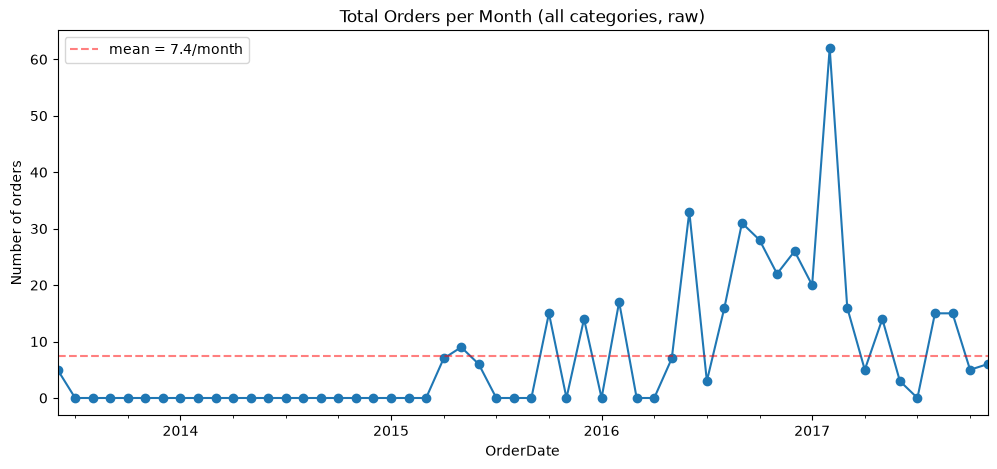

In [13]:
import matplotlib.pyplot as plt

monthly_order_counts = orders.set_index('OrderDate').resample('MS').size()

fig, ax = plt.subplots(figsize=(12,5))
monthly_order_counts.plot(marker='o', ax=ax)
ax.set_title('Total Orders per Month (all categories, raw)')
ax.set_ylabel('Number of orders')
ax.axhline(monthly_order_counts.mean(), color='red', linestyle='--', alpha=0.5,
           label=f'mean = {monthly_order_counts.mean():.1f}/month')
ax.legend()
plt.show()

In [14]:
daily_order_counts = orders.set_index('OrderDate').resample('D').size()
total_days = len(daily_order_counts)
days_with_orders = (daily_order_counts > 0).sum()
print(f"Days with at least one order: {days_with_orders} ({days_with_orders/total_days*100:.1f}%)")

Days with at least one order: 75 (4.7%)
